In [1]:
# ================================
# Basic imports
# ================================
import sys
import warnings
import numpy as np
import pandas as pd
from numpy import loadtxt, savetxt
from scipy.integrate import cumulative_trapezoid
import matplotlib as mpl
import matplotlib.pyplot as plt

# ================================
# GaPP imports
# ================================
from gapp import gp
from gapp import covariance

# ================================
# Matplotlib global configuration
# ================================
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Nimbus Roman"]
})

# ===================
# Warning control
# ===================
# We suppress only generic UserWarnings to avoid hiding serious numerical issues.
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
# Physical constants
c = 299792.458

In [3]:
# =============================================================================
# 1st part of the work

# Reconstructing H(z) function using CC data
# =============================================================================

  NIT   NF   F                       GTG
    0    1  1.501586188990255E+02   2.44256527E+00
    1    4  1.490863511668585E+02   7.27421076E-02
    2    6  1.489905325599217E+02   9.61530268E-06
    3    8  1.489891921163452E+02   1.21642249E-03
    4   10  1.489865913849300E+02   1.57853066E-04
tnc: fscale = 36.4189
    5   12  1.489864760188026E+02   3.94671215E-07
    6   14  1.489864688067110E+02   1.36166564E-08
tnc: fscale = 3480.57
tnc: |fn-fn-1] = 1.28353e-08 -> convergence
    7   16  1.489864687938757E+02   4.98617821E-11
tnc: Converged (|f_n-f_(n-1)| ~= 0)



Optimized hyperparameters:
theta = [135.0243126    1.96180278]
z = 0.000 | H0 = 67.486 | sigH0 = 4.577 | sigH0/H0 (%) = 6.78


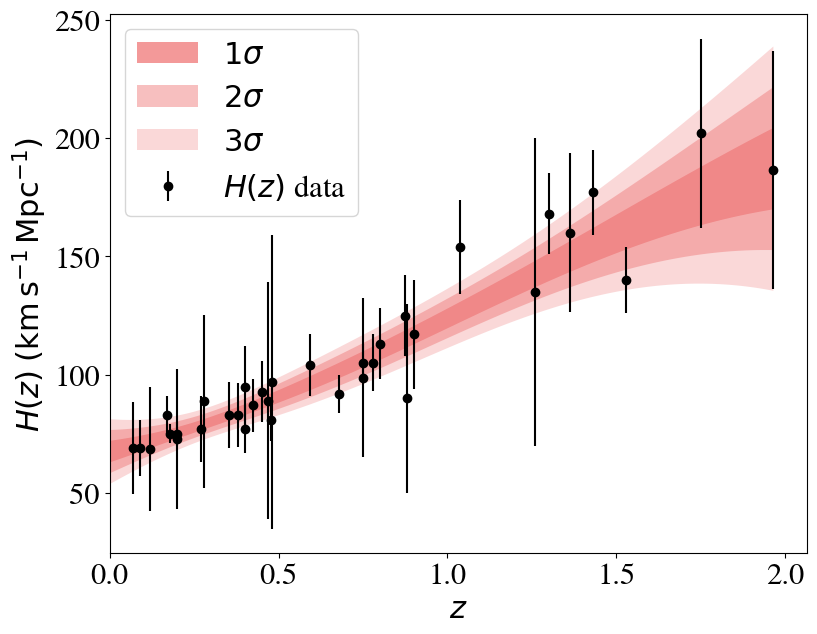

In [4]:
# =============================================================================
# Main execution
# =============================================================================

if __name__ == "__main__":

    # -----------------------------------------
    # Loading CC data
    # -----------------------------------------
    cc_dat_path = "/home/brunowesley/projetos/GaPP/Hz_CC_data.txt"

    # DataFrame
    df_cc = pd.read_csv(cc_dat_path, sep=r"\s+")

    # Main columns
    Z     = df_cc["z_cc"].to_numpy(float)
    Hz    = df_cc["H_cc"].to_numpy(float)
    Sigma = df_cc["H_cc_err"].to_numpy(float)


    # -----------------------------------------
    # Gaussian Process reconstruction of H(z)
    # -----------------------------------------

    # Reconstruction range:
    # from z = 0 up to the maximum redshift in the data
    zmin = 0.0
    zmax = np.max(Z)

    # Instantiate the Gaussian Process with a Squared Exponential kernel
    g1 = gp.GaussianProcess(
        Z,
        Hz,
        Sigma,
        covfunction=covariance.SquaredExponential,
        cXstar=(zmin, zmax, 200)  # 200 reconstruction points between zmin and zmax
    )

    # Perform GP reconstruction and hyperparameter training
    rec1, theta1 = g1.gp(thetatrain="True")


    # -----------------------------------------
    # Extract reconstructed quantities
    # -----------------------------------------
   
    # rec1 columns follow GaPP convention:

    zrec = rec1[:, 0]         # column 0 -> reconstructed z
    hzrec = rec1[:, 1]        # column 1 -> reconstructed H(z)
    sighzrec = rec1[:, 2]     # column 2 -> 1-sigma uncertainty on H(z)


    # -----------------------------------------
    # Print H0 estimate (H at z = 0)
    # -----------------------------------------
    H0 = hzrec[0]
    sigH0 = sighzrec[0]

    print(
        f"z = {zrec[0]:.3f} | "
        f"H0 = {H0:.3f} | "
        f"sigH0 = {sigH0:.3f} | "
        f"sigH0/H0 (%) = {(sigH0 / H0) * 100:.2f}"
    )


    # -----------------------------------------
    # Save reconstructed H(z)
    # -----------------------------------------
    savetxt("Hz_CC_rec.dat", rec1)


    # =========================================================================
    # Plotting: data + GP reconstruction
    # =========================================================================
        
    plt.rc("text", usetex=False)
    plt.rc("font", family="serif")

    fig, ax = plt.subplots(figsize=(9, 7))

    # Axis labels
    ax.set_xlabel(r"$z$", fontsize=22)
    ax.set_ylabel(
        r"$H(z)\;(\mathrm{km}\,\mathrm{s}^{-1}\,\mathrm{Mpc}^{-1})$",
        fontsize=22
    )

    # Axis limits
    ax.set_xlim(zmin, zmax + 0.1)

    # Tick font sizes
    ax.tick_params(axis="both", labelsize=22)

    # Plot observational data
    data_plot = ax.errorbar(
        Z, Hz, yerr=Sigma,
        fmt="o",
        color="black",
        label=r"$H(z)$ data"
    )

    # Plot GP confidence regions
    band1 = ax.fill_between(
        zrec,
        hzrec - sighzrec,
        hzrec + sighzrec,
        facecolor="#F08080",
        alpha=0.80,
        label=r"$1\sigma$"
    )

    band2 = ax.fill_between(
        zrec,
        hzrec - 2.0 * sighzrec,
        hzrec + 2.0 * sighzrec,
        facecolor="#F08080",
        alpha=0.50,
        label=r"$2\sigma$"
    )

    band3 = ax.fill_between(
        zrec,
        hzrec - 3.0 * sighzrec,
        hzrec + 3.0 * sighzrec,
        facecolor="#F08080",
        alpha=0.30,
        label=r"$3\sigma$"
    )

    # Legend (explicit order for robustness)
    ax.legend(
        [band1, band2, band3, data_plot],
        [r"$1\sigma$", r"$2\sigma$", r"$3\sigma$", r"$H(z)$ data"],
        fontsize=22,
        loc="upper left"
    )

    # Save figure before showing it
    fig.savefig(
        "Hz_CC_rec.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [5]:
# =============================================================================
# 2nd part of the work

# Reconstructing DM(z), DH(z), and DV(z) BAO 
# quantities from the H(z) reconstructed above
# =============================================================================

In [6]:
# =========================================================================
# Cosmological distances from reconstructed H(z)
# =========================================================================


# --------------------------------------------------------------
# Hubble distance
# --------------------------------------------------------------
# DH(z) = c / H(z)
DH = c / hzrec

# sigma_DH / DH = sigma_H / H
sigDH = DH * (sighzrec / hzrec) 


# --------------------------------------------------------------
# Comoving transverse distance
# --------------------------------------------------------------
# DM(z) = c * ∫ dz / H(z)
integrand = 1.0 / hzrec
DM = c * cumulative_trapezoid(integrand, zrec, initial=0.0)

# σ_DM^2 = c^2 ∫ [σ_H(z) / H(z)^2]^2 dz
integrand_err = (sighzrec / hzrec**2) ** 2
sigDM = c * np.sqrt(cumulative_trapezoid(integrand_err, zrec, initial=0.0))


# --------------------------------------------------------------
# Volume-averaged distance
# --------------------------------------------------------------
# DV(z) = [ z * DM^2 * DH ]^(1/3)
DV = (zrec * DM**2 * DH) ** (1.0 / 3.0)

# Error propagation (logarithmic differentiation)
sigDV = DV * np.sqrt(
    (2.0 / 3.0 * sigDM / DM) ** 2 +
    (1.0 / 3.0 * sigDH / DH) ** 2
)


# Avoid numerical issues at z = 0
DV[0] = 0.0
sigDV[0] = 0.0

/tmp/ipykernel_1365823/1235981157.py:36: RuntimeWarning: invalid value encountered in divide
  (2.0 / 3.0 * sigDM / DM) ** 2 +


In [7]:
# =========================================================================
# Save reconstructed distances
# =========================================================================

savetxt(
    "BAO_dist_rec.dat",
    np.column_stack([zrec, DH, sigDH, DM, sigDM, DV, sigDV]),
    header="z  DH  sigDH  DM  sigDM  DV  sigDV"
)

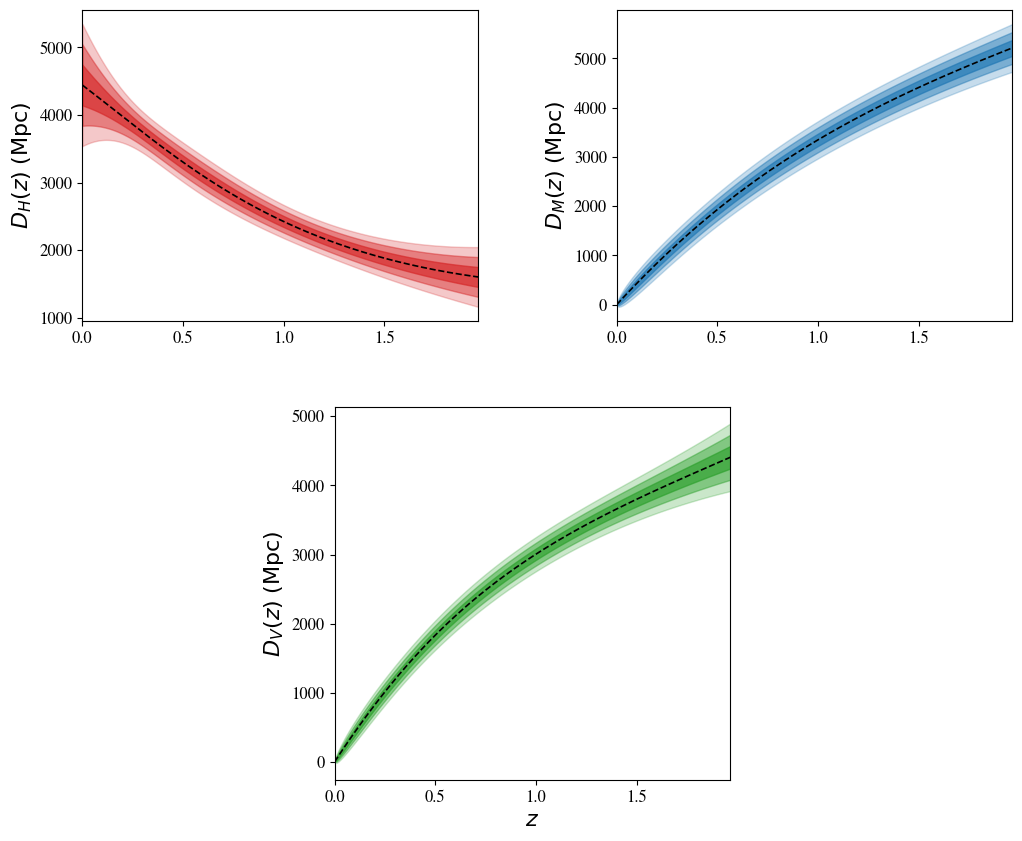

In [8]:
# =========================================================================
# Combined plot: DH(z), DM(z), DV(z) in custom layout (A, B, C)
# =========================================================================

fig = plt.figure(figsize=(12, 10))

# Create GridSpec: 2 rows, 2 columns
gs = fig.add_gridspec(
    nrows=2,
    ncols=2,
    height_ratios=[1, 1.2],  # bottom plot slightly taller
    hspace=0.25,
    wspace=0.35
)

# Axes definition
ax_DH = fig.add_subplot(gs[0, 0])   # Plot A
ax_DM = fig.add_subplot(gs[0, 1])   # Plot B
ax_DV = fig.add_subplot(gs[1, 0])   # Plot C (single column, will be centered)

# -------------------------------------------------------------------------
# Center Plot C horizontally
# -------------------------------------------------------------------------
pos = ax_DV.get_position()
new_width = pos.width
new_x0 = 0.5 - new_width / 2.0   # center horizontally

ax_DV.set_position([new_x0, pos.y0, new_width, pos.height])


# =========================================================================
# Plot A: DH(z)
# =========================================================================
ax_DH.plot(zrec, DH, color="black", ls="--", lw=1.2)

ax_DH.fill_between(zrec, DH - 3*sigDH, DH + 3*sigDH,
                   color="#D62728", alpha=0.25)
ax_DH.fill_between(zrec, DH - 2*sigDH, DH + 2*sigDH,
                   color="#D62728", alpha=0.45)
ax_DH.fill_between(zrec, DH - sigDH, DH + sigDH,
                   color="#D62728", alpha=0.65)

ax_DH.set_ylabel(r"$D_H(z)\;(\mathrm{Mpc})$", fontsize=16)
ax_DH.tick_params(axis="both", labelsize=12)

# =========================================================================
# Plot B: DM(z)
# =========================================================================
ax_DM.plot(zrec, DM, color="black", ls="--", lw=1.2)

ax_DM.fill_between(zrec, DM - 3*sigDM, DM + 3*sigDM,
                   color="#1f77b4", alpha=0.25)
ax_DM.fill_between(zrec, DM - 2*sigDM, DM + 2*sigDM,
                   color="#1f77b4", alpha=0.45)
ax_DM.fill_between(zrec, DM - sigDM, DM + sigDM,
                   color="#1f77b4", alpha=0.65)

ax_DM.set_ylabel(r"$D_M(z)\;(\mathrm{Mpc})$", fontsize=16)
ax_DM.tick_params(axis="both", labelsize=12)

# =========================================================================
# Plot C: DV(z)
# =========================================================================
ax_DV.plot(zrec, DV, color="black", ls="--", lw=1.2)

ax_DV.fill_between(zrec, DV - 3*sigDV, DV + 3*sigDV,
                   color="#2CA02C", alpha=0.25)
ax_DV.fill_between(zrec, DV - 2*sigDV, DV + 2*sigDV,
                   color="#2CA02C", alpha=0.45)
ax_DV.fill_between(zrec, DV - sigDV, DV + sigDV,
                   color="#2CA02C", alpha=0.65)

ax_DV.set_xlabel(r"$z$", fontsize=16)
ax_DV.set_ylabel(r"$D_V(z)\;(\mathrm{Mpc})$", fontsize=16)
ax_DV.tick_params(axis="both", labelsize=12)

# =========================================================================
# Axis limits
# =========================================================================
ax_DH.set_xlim(zrec[0], zrec[-1])
ax_DM.set_xlim(zrec[0], zrec[-1])
ax_DV.set_xlim(zrec[0], zrec[-1])

# =========================================================================
# Save and show
# =========================================================================
fig.savefig(
    "BAO_dist_rec.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()